In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

In [3]:
df = pd.read_csv(r"developer_burnout_dataset_7000.csv")
df.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (7000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,6860.0,32.129446,7.230254,20.00,26.0000,32.000,38.0000,44.00
experience_years,6860.0,9.581050,5.760972,0.00,5.0000,10.000,15.0000,19.00
daily_work_hours,6860.0,9.000277,2.863944,4.00,6.5600,8.990,11.4225,14.00
sleep_hours,6860.0,6.485638,1.445008,4.00,5.2200,6.460,7.7400,9.00
caffeine_intake,6860.0,3.540671,2.283445,0.00,2.0000,4.000,6.0000,7.00
bugs_per_day,6860.0,9.482653,5.751664,0.00,5.0000,9.000,14.0000,19.00
commits_per_day,6860.0,14.458455,8.669846,0.00,7.0000,14.000,22.0000,29.00
meetings_per_day,6860.0,4.545044,2.856766,0.00,2.0000,5.000,7.0000,9.00
screen_time,6860.0,11.974773,3.091204,5.21,9.4600,12.020,14.4225,18.93
exercise_hours,6860.0,1.007611,0.576708,0.00,0.5100,1.020,1.5100,2.00


In [6]:
df.isnull().sum()

age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

In [7]:
df = df.dropna()
df.isnull().sum()

age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
stress_level        0
burnout_level       0
dtype: int64

In [8]:
df = df[df["burnout_level"].notna()].copy()

df["burnout_level"] = df["burnout_level"].map({
    "High": 1,
    "Medium": 0,
    "Low": 0
})

df["burnout_level"].value_counts()

burnout_level
0    4037
1    1453
Name: count, dtype: int64

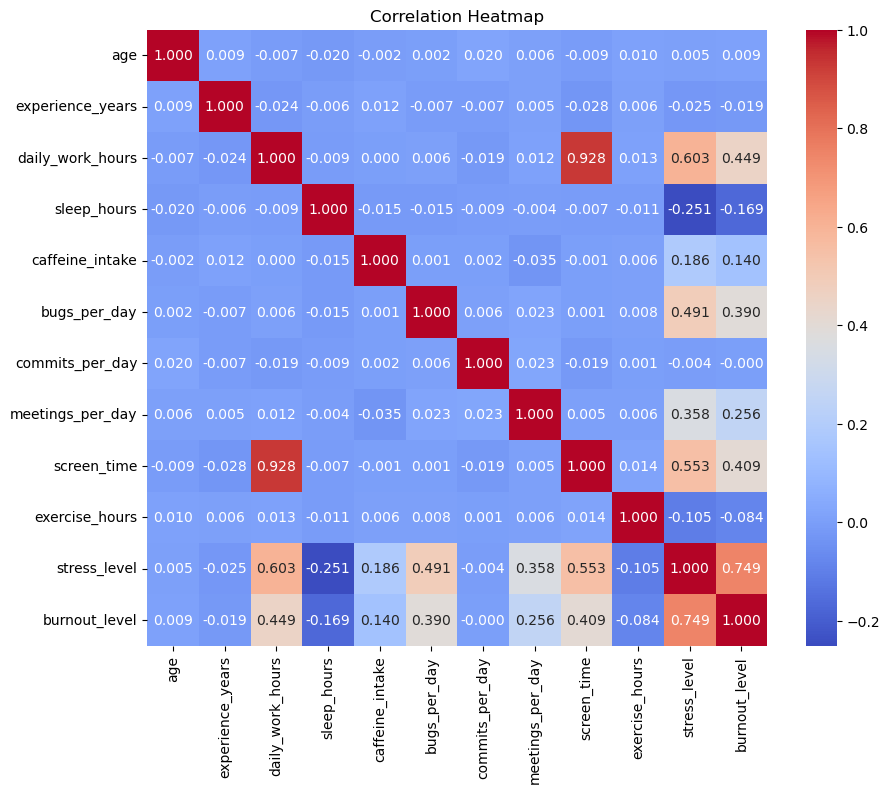

In [9]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap")
plt.show()

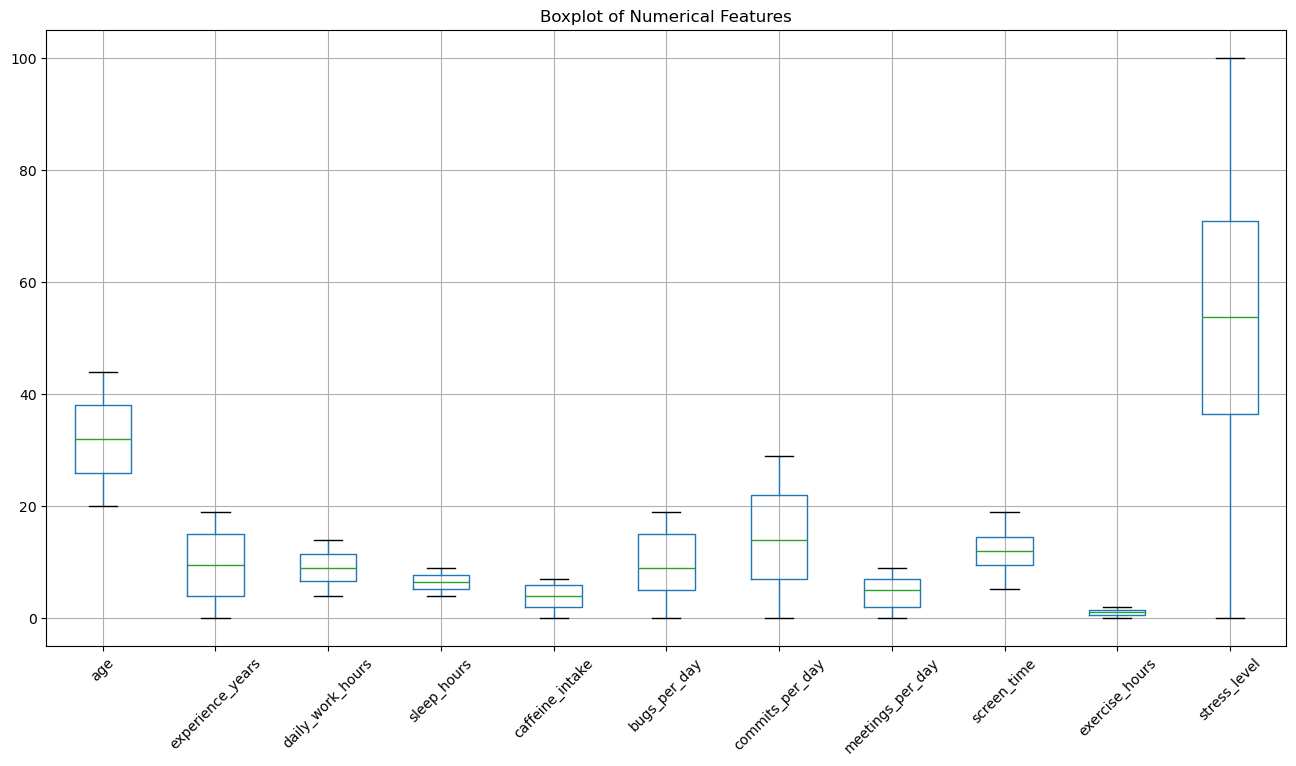

In [10]:
numeric_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != "burnout_level"]

plt.figure(figsize=(16, 8))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [12]:
df_final = df.drop(columns=["stress_level", "commits_per_day", "screen_time"])
print(df_final.head())

    age  experience_years  daily_work_hours  sleep_hours  caffeine_intake  \
0  26.0              12.0             10.33         4.45              2.0   
1  39.0              10.0              8.62         5.77              5.0   
3  30.0               1.0              6.85         6.47              2.0   
5  40.0               2.0             10.25         6.78              0.0   
7  38.0               0.0             10.69         5.25              5.0   

   bugs_per_day  meetings_per_day  exercise_hours  burnout_level  
0          11.0               1.0            0.14              0  
1          15.0               5.0            0.54              1  
3          15.0               1.0            0.96              0  
5          19.0               4.0            0.78              0  
7          12.0               2.0            0.10              1  


In [13]:
X = df_final.drop(columns=["burnout_level"])
y = df_final["burnout_level"]

print(X.shape)
print(y.shape)

(5490, 8)
(5490,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3678, 8)
X_test shape: (1812, 8)


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred_log = log_model.predict(X_test_scaled)
y_score_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [18]:
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC :", roc_auc_score(y_test, y_score_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

F1-score: 0.7699018538713195
ROC-AUC : 0.9406938188188189

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1332
           1       0.81      0.74      0.77       480

    accuracy                           0.88      1812
   macro avg       0.86      0.84      0.85      1812
weighted avg       0.88      0.88      0.88      1812



In [19]:
print(df["burnout_level"].unique())

[0 1]


[[1248   84]
 [ 127  353]]


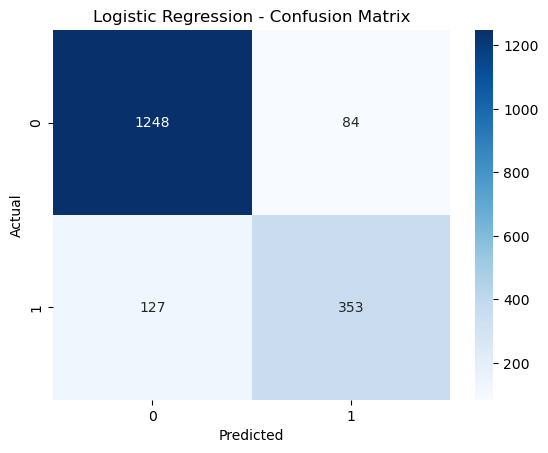

In [20]:
cm_log = confusion_matrix(y_test, y_pred_log)
print(cm_log)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

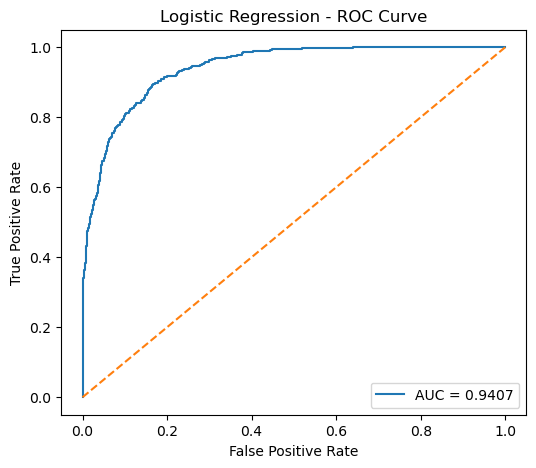

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_score_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score_log):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend(loc="lower right")
plt.show()

SVM Model

In [22]:
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_score_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [24]:
print("F1-score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC :", roc_auc_score(y_test, y_score_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

F1-score: 0.763873775843308
ROC-AUC : 0.9398390578078079

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1332
           1       0.80      0.73      0.76       480

    accuracy                           0.88      1812
   macro avg       0.85      0.83      0.84      1812
weighted avg       0.88      0.88      0.88      1812



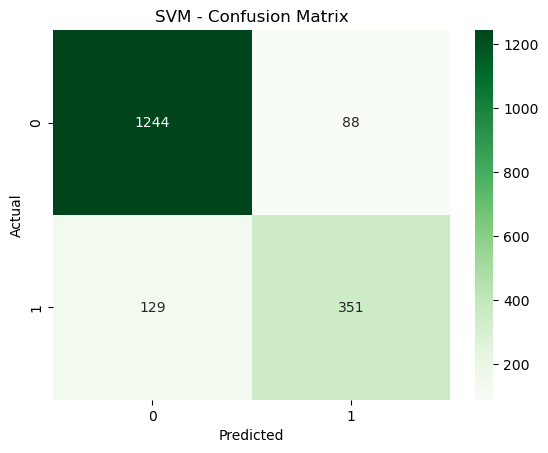

In [25]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens")
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

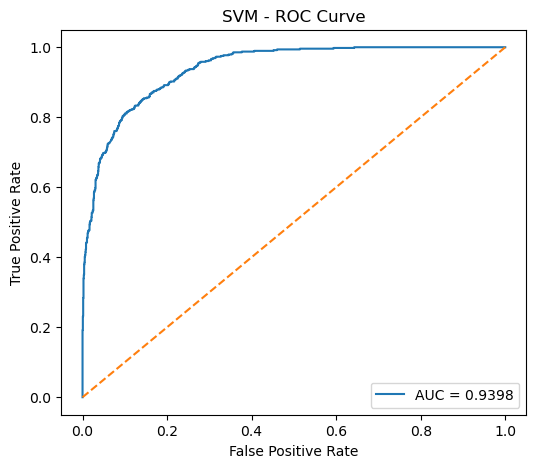

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_score_svm)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score_svm):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM - ROC Curve")
plt.legend(loc="lower right")
plt.show()

Random Forest Model

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred_rf = rf_model.predict(X_test)
y_score_rf = rf_model.predict_proba(X_test)[:, 1]

In [29]:
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC :", roc_auc_score(y_test, y_score_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

F1-score: 0.7251732101616628
ROC-AUC : 0.9306181181181181

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1332
           1       0.81      0.65      0.73       480

    accuracy                           0.87      1812
   macro avg       0.85      0.80      0.82      1812
weighted avg       0.87      0.87      0.86      1812



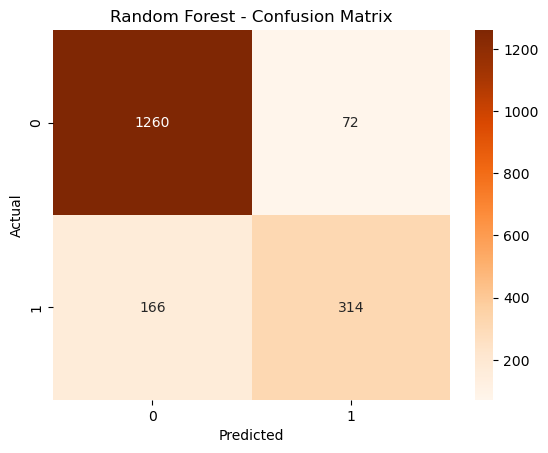

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

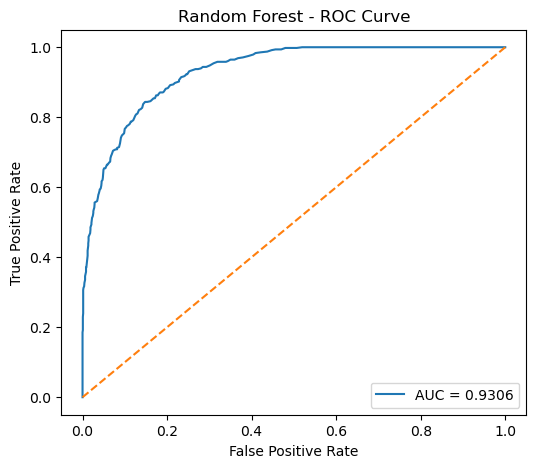

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_score_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score_rf):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

            Feature  Importance
2  daily_work_hours    0.296080
5      bugs_per_day    0.218707
6  meetings_per_day    0.113034
3       sleep_hours    0.110090
7    exercise_hours    0.083827
4   caffeine_intake    0.060569
0               age    0.059551
1  experience_years    0.058141


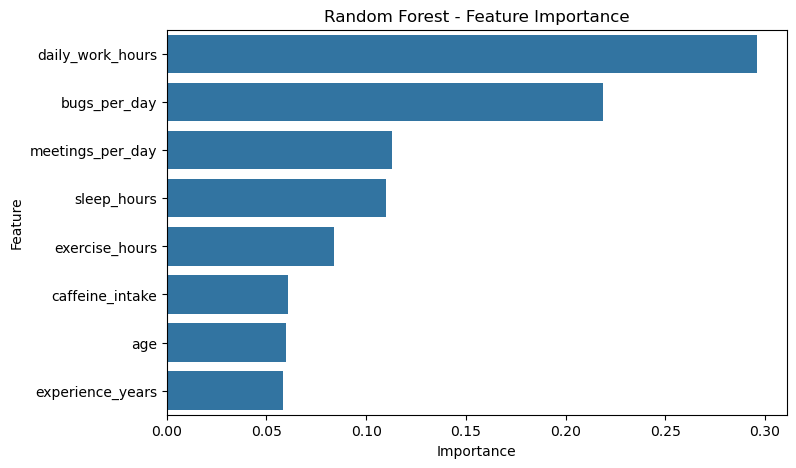

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest - Feature Importance")
plt.show()

In [35]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 875.4 kB/s eta 0:01:56
   ---------------------------------------- 0.8/101.7 MB 1.1 MB/s eta 0:01:29
   ---------------------------------------- 1.0/101.7 MB 1.3 MB/s eta 0:01:18
    --------------------------------------- 1.6/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 2.1/101.7 MB 1.6 MB/s eta 0:01:02
   - -------------------------------------- 2.6/101.7 MB 1.8 MB/s eta 0:00:55
   - -------------------------------------- 3.4/101.7 MB 2.0 MB/s eta 0:00:49
   - -------------------------------------- 3.4/101.7 MB 2.0 MB/s eta 0:00:49
   - -------------------------------------- 4.2/101.7 MB 2.0 MB/s eta 0:00:48
   - -------

In [36]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [37]:
y_pred_xgb = xgb_model.predict(X_test)
y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [38]:
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC :", roc_auc_score(y_test, y_score_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

F1-score: 0.7353878852284803
ROC-AUC : 0.9278731856856857

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1332
           1       0.75      0.72      0.74       480

    accuracy                           0.86      1812
   macro avg       0.83      0.82      0.82      1812
weighted avg       0.86      0.86      0.86      1812



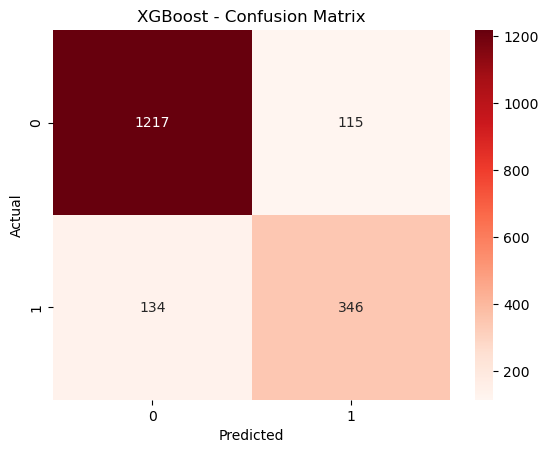

In [39]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

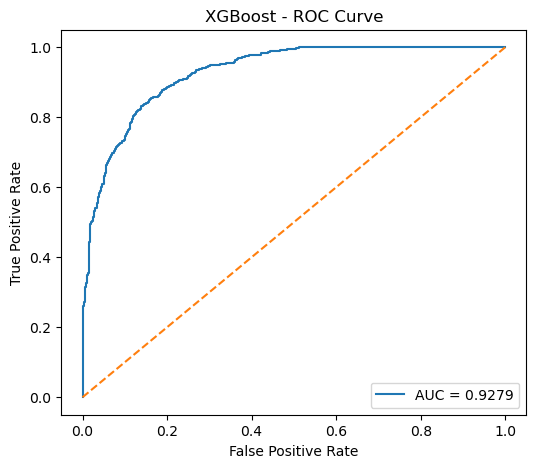

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_score_xgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score_xgb):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost - ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [41]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(xgb_importance)

            Feature  Importance
5      bugs_per_day    0.263425
2  daily_work_hours    0.214759
6  meetings_per_day    0.195393
4   caffeine_intake    0.104627
3       sleep_hours    0.084302
7    exercise_hours    0.056212
1  experience_years    0.042997
0               age    0.038285


In [45]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "XGBoost"],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_score_log),
        roc_auc_score(y_test, y_score_svm),
        roc_auc_score(y_test, y_score_rf),
        roc_auc_score(y_test, y_score_xgb)
    ]
})

results = results.sort_values(by="F1-score", ascending=False)
print(results)

                 Model  F1-score   ROC-AUC
0  Logistic Regression  0.769902  0.940694
1                  SVM  0.763874  0.939839
3              XGBoost  0.735388  0.927873
2        Random Forest  0.725173  0.930618


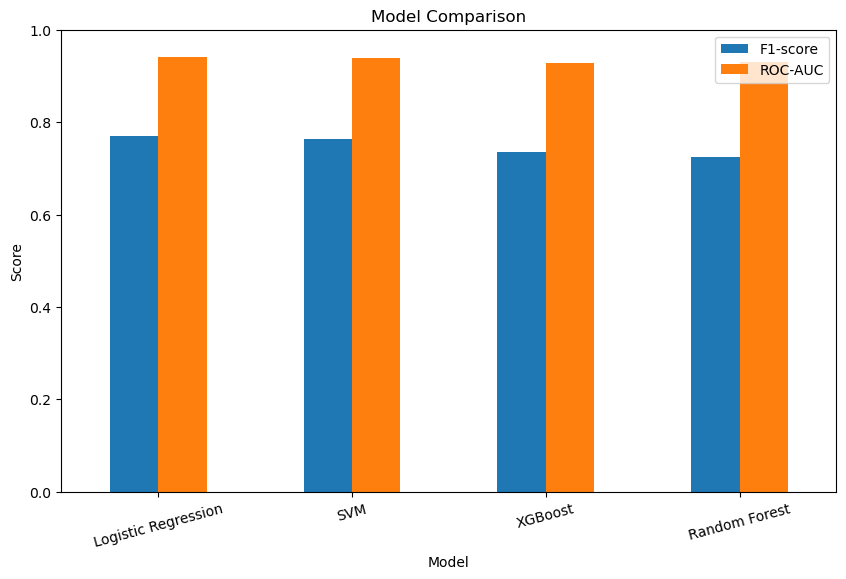

In [46]:
results_plot = results.set_index("Model")

results_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

In [47]:
best_model = results.iloc[0]
print("Best Model:", best_model["Model"])
print("Best F1-score:", best_model["F1-score"])
print("Best ROC-AUC:", best_model["ROC-AUC"])

Best Model: Logistic Regression
Best F1-score: 0.7699018538713195
Best ROC-AUC: 0.9406938188188189
